In [1]:
import utils
import models
import dataset
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2


In [2]:
X, Y = dataset.load_data()
X_train, Y_train, X_test, Y_test = dataset.partition_data(X, Y, split_ratio = [.8, .2])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
end_plot = 1000


Epoch 1/20 | Train Loss: 0.8573 | Val Loss: 0.8814
Epoch 3/20 | Train Loss: 0.7630 | Val Loss: 0.8406
Epoch 5/20 | Train Loss: 0.7513 | Val Loss: 0.8334
Epoch 7/20 | Train Loss: 0.7453 | Val Loss: 0.8284
Epoch 9/20 | Train Loss: 0.7412 | Val Loss: 0.8258
Epoch 11/20 | Train Loss: 0.7390 | Val Loss: 0.8233
Epoch 13/20 | Train Loss: 0.7368 | Val Loss: 0.8219
Epoch 15/20 | Train Loss: 0.7355 | Val Loss: 0.8211
Epoch 17/20 | Train Loss: 0.7335 | Val Loss: 0.8190
Epoch 19/20 | Train Loss: 0.7324 | Val Loss: 0.8174
Epoch 20/20 | Train Loss: 0.7316 | Val Loss: 0.8173


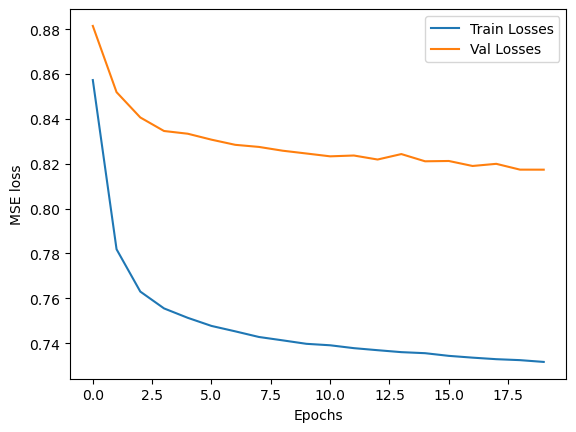

In [11]:
lstm = models.LSTM(epochs = 20)

lstm.train_model(X_train, Y_train, plot = True)

lstm_yhat = lstm.run_model(X_test)

In [5]:
kf = models.KalmanFilter()

kf.train_model(X_train, Y_train)

kf_yhat = kf.run_model(X_test, Y_test[0, :])

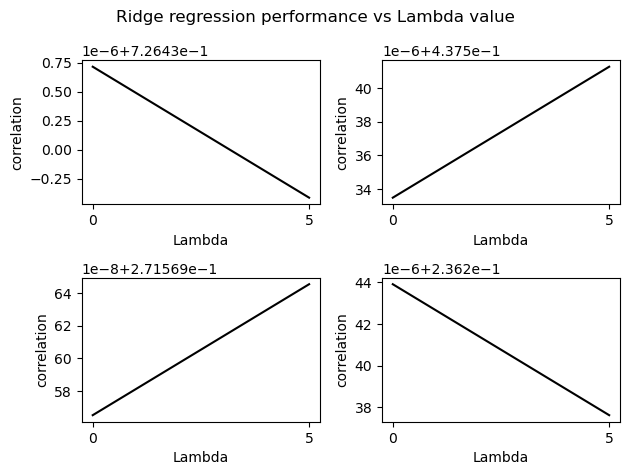

In [6]:
rr = models.RidgeRegression()

rr.train_model(X_train, Y_train)

RR_yhat = rr.run_model(X_test, Y_test[0, :])

In [7]:
lr = models.RidgeRegression(lbda=1)

lr.train_model(X_train, Y_train)

lr_yhat = lr.run_model(X_test, Y_test[0, :])

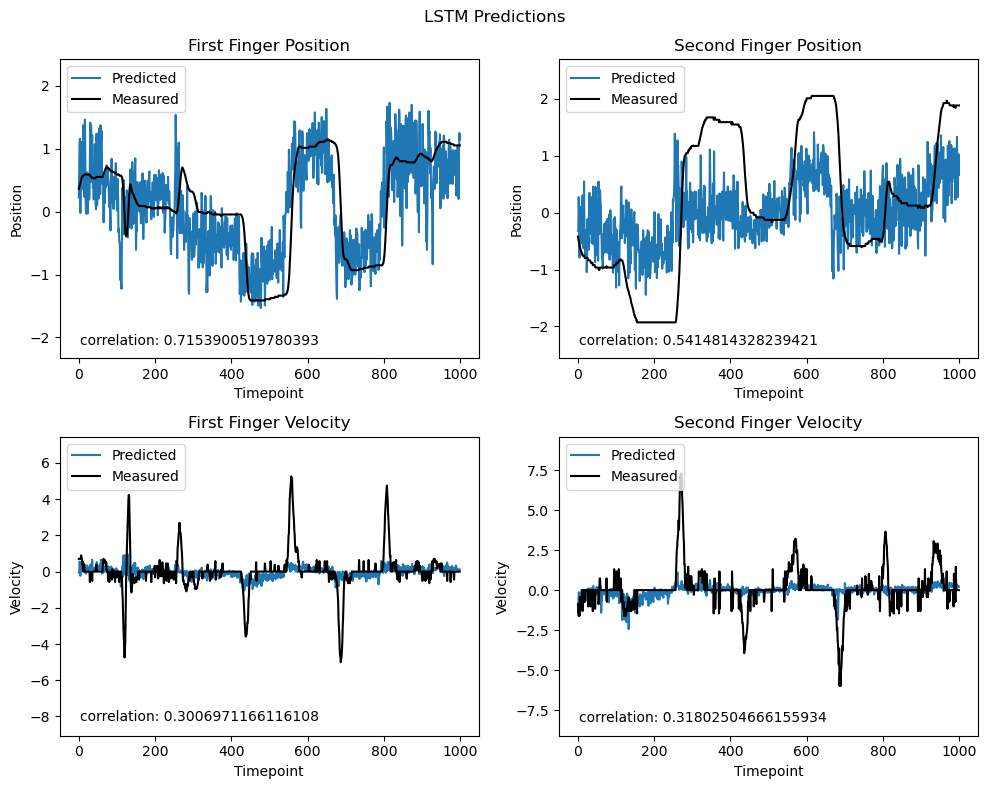

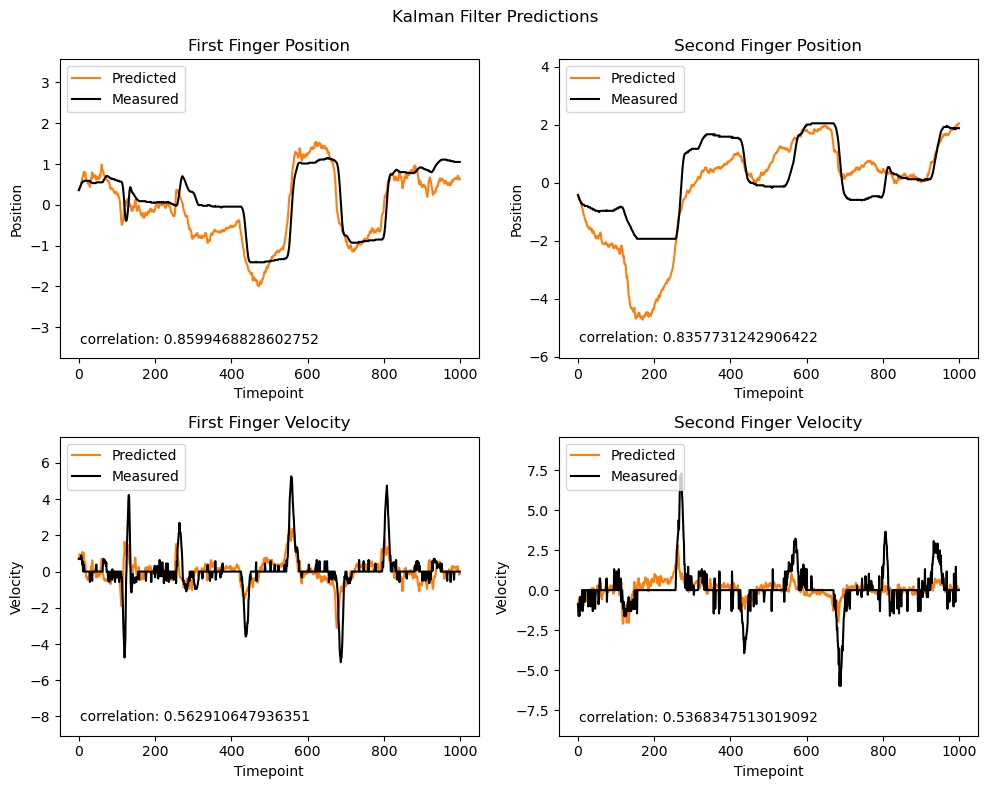

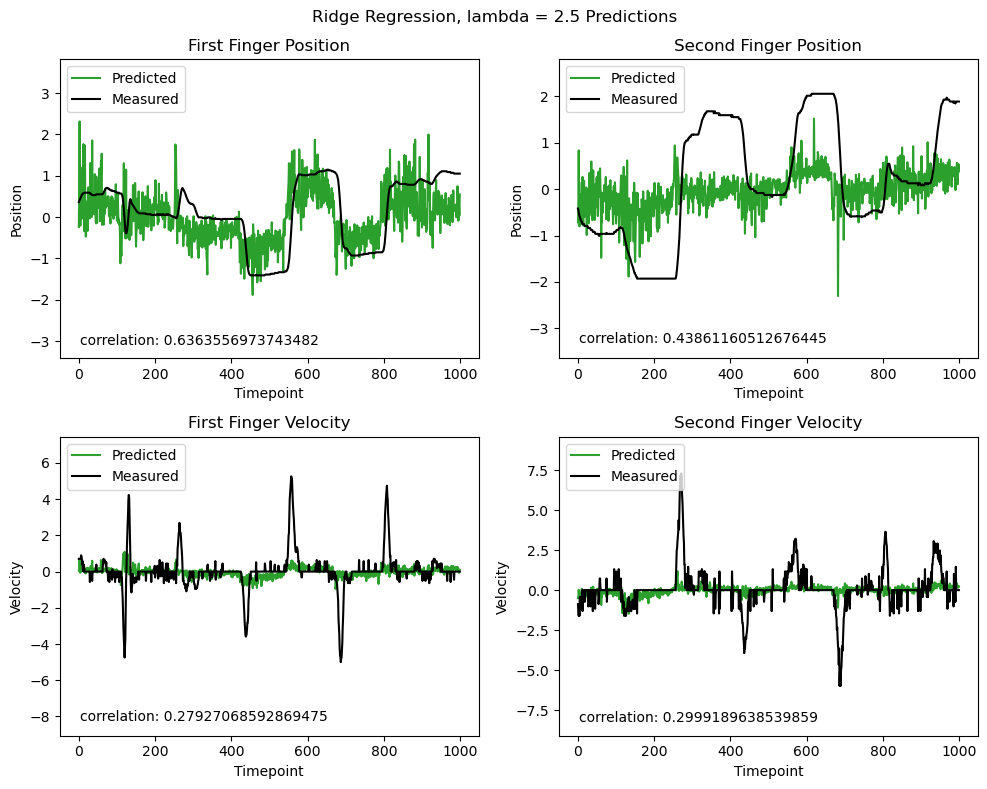

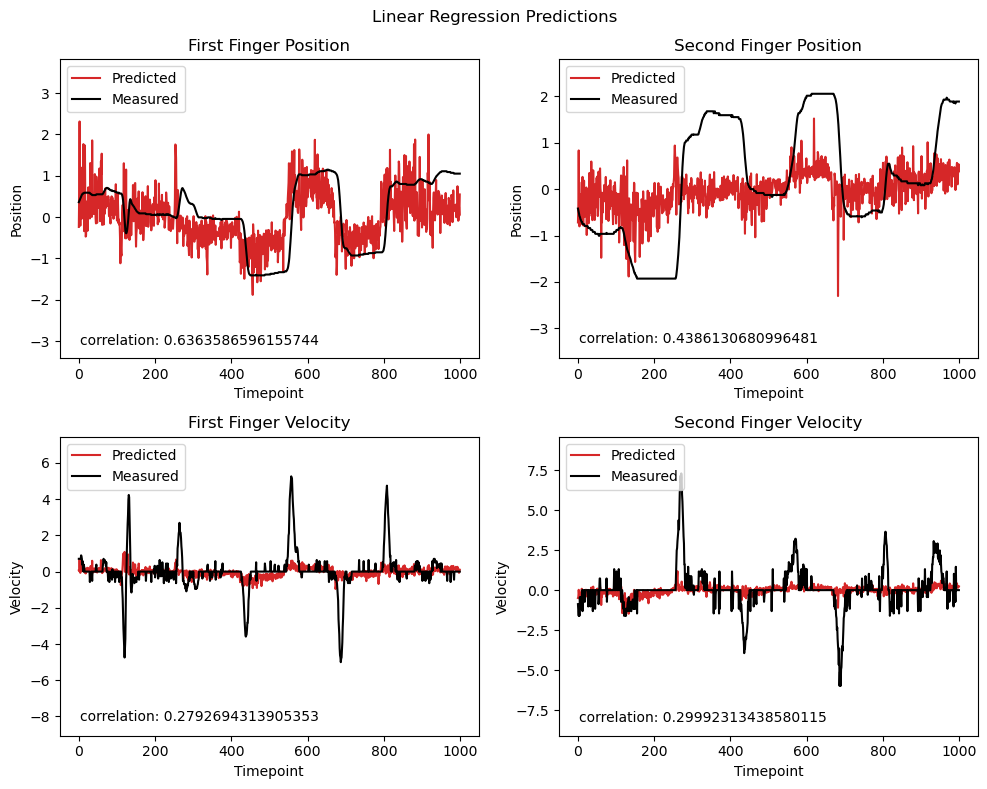

In [8]:
utils.plot_predictions(Y_test, lstm_yhat, title = f"{lstm.name} Predictions", color = colors[0], end = end_plot)
utils.plot_predictions(Y_test, kf_yhat, title = f"{kf.name} Predictions", color = colors[1], end = end_plot)
utils.plot_predictions(Y_test, RR_yhat, title = f"{rr.name} Predictions", color = colors[2], end = end_plot)
utils.plot_predictions(Y_test, lr_yhat, title = f"{lr.name} Predictions", color = colors[3], end = end_plot)

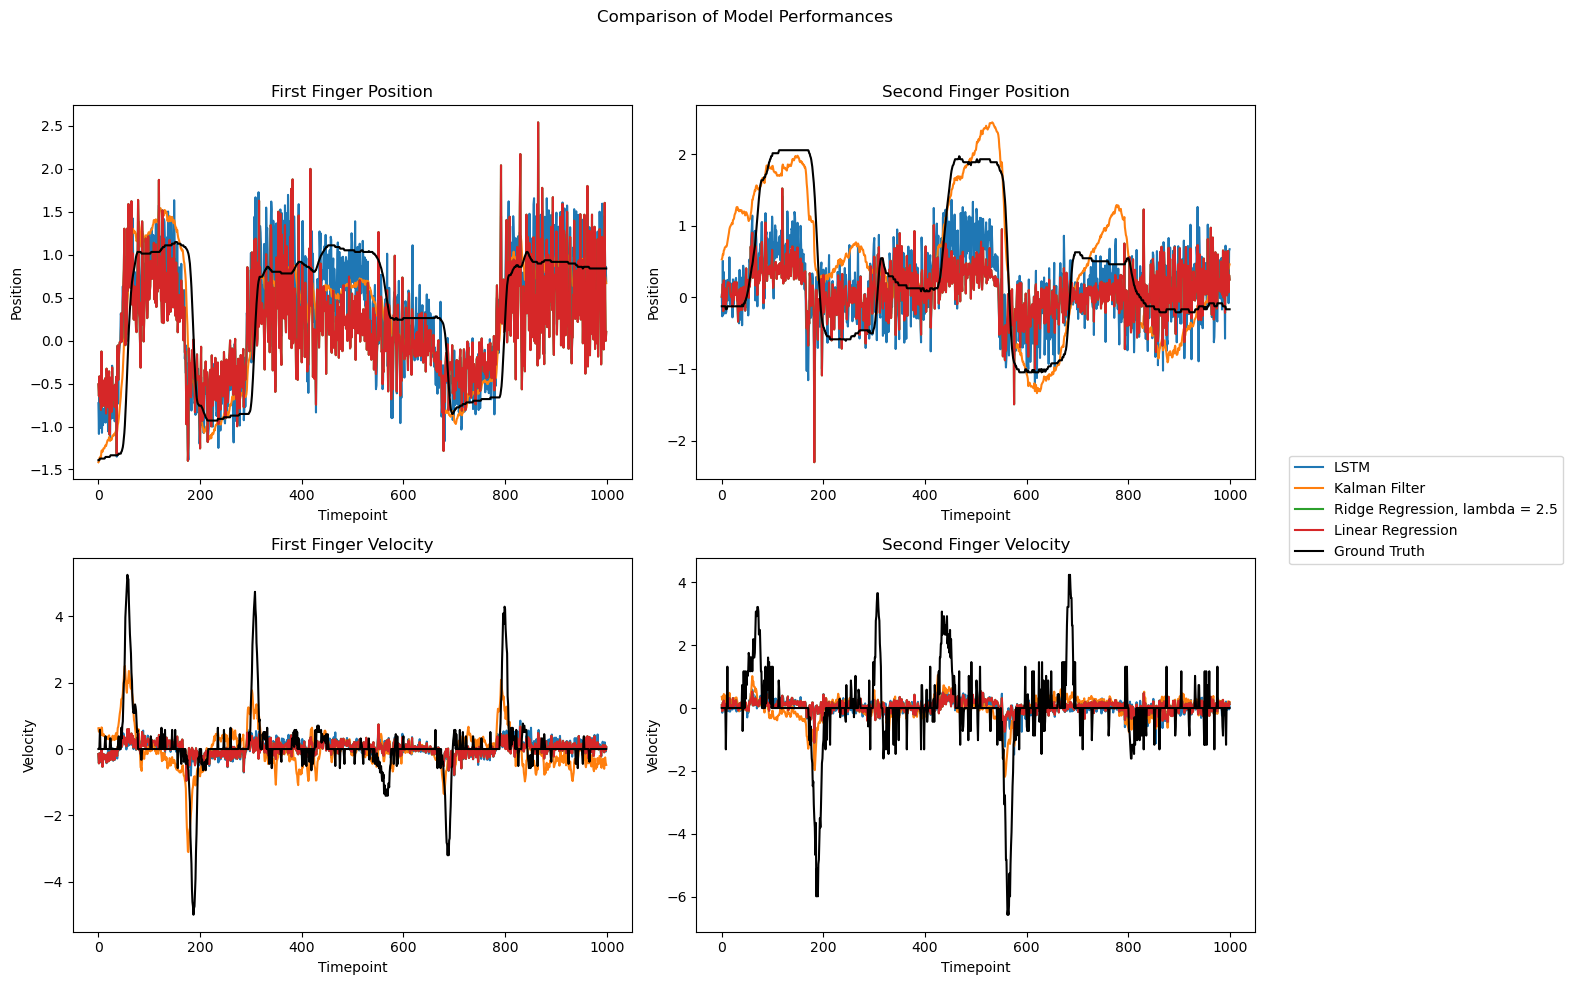

In [10]:
start = 500
utils.compare_perfs(Y_test, yhats = [lstm_yhat, kf_yhat, RR_yhat, lr_yhat], model_labels = [lstm.name, kf.name, rr.name, lr.name], colors = colors, start = start, end = start+end_plot)